In [ ]:
# 필수 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import time
import copy

In [ ]:
# 한글 폰트 설정 (Colab)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 고정
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
if torch.cuda.is_available():
    print(f'GPU 이름: {torch.cuda.get_device_name(0)}')

사용 디바이스: cuda
GPU 이름: Tesla T4


**데이터 증강 기법:**
- `RandomHorizontalFlip`: 좌우 반전
- `RandomCrop`: 랜덤 자르기
- `ColorJitter`: 밝기, 대비, 채도 조정
- `Normalize`: ImageNet 평균과 표준편차로 정규화

In [ ]:
# 데이터 변환 정의
def get_transforms():
    # 훈련 데이터 변환(데이터 증강)
    train_transform = transforms.Compose(
        [
            transforms.Resize(128), # 크기조정
            transforms.RandomCrop(112),
            transforms.RandomHorizontalFlip(p=0.5), # 좌우반전(50% 확률로)
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 색상변환

            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.405], std=[0.229, 0.224, 0.225])
        ])
    # 검증 데이터 변환 (증강 없어야 함)
    val_transform = transforms.Compose(
        [
            transforms.Resize(112), # 크기조정 Resize((112, 112))
            # transforms.CenterCrop(112), # 중앙에 위치 112*112로 잘라서 만들어줘(정보 손실 가능)

            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.405], std=[0.229, 0.224, 0.225])
        ])
    return train_transform, val_transform

In [ ]:
# CIFAR-10 데이터 셋 로드

def load_data(batch_size=64):
    train_transform, val_transform = get_transforms()

    # 훈련데이터
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=train_transform
    )

    # 검증데이터
    val_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=val_transform
    )

    # 데이터 로더 생성
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True # GPU 전송 속도 향상
   )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True # GPU 전송 속도 향상
   )
    return train_loader, val_loader

In [ ]:
# 데이터 로드
train_loader, val_loader = load_data(batch_size=64)

In [ ]:
# 클래스 이름
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'훈련 데이터: {len(train_loader.dataset)}개')
print(f'검증 데이터: {len(val_loader.dataset)}개')
print(f'배치 크기: {train_loader.batch_size}')

훈련 데이터: 50000개
검증 데이터: 10000개
배치 크기: 64


모델 생성 및 수정

In [ ]:
# 원래 resnet 은 imagenet 에 사용된 사전학습된 가중치임
# 이 모델은 1000개 클래스 분류하는 분류기
# 우리 모델에 맞춤 서비스 하기 위해 마지막 fc layer (분류기 classfier) 10개 클래스로 변경 작업 필요

model = models.resnet18(weights='IMAGENET1K_V1')
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
print(model.fc)
print(model.fc.in_features)

Linear(in_features=512, out_features=1000, bias=True)
512


In [ ]:
def create_model(num_classes=10, pretrained=True):
    model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)

    # 마지막 분류기(fc) 입력 차원
    num_features = model.fc.in_features

    num_classes = 10

    model.fc = nn.Linear(num_features, num_classes)

    model = model.to(device)

    return model

In [ ]:
# 모델 생성
model = create_model(num_classes=10, pretrained=True)

In [ ]:
# 모델 파라미터(학습 대상) 수 확인
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'모델 총 파라미터 수: {total_params:,}')
print(f'학습 가능한 파라미터 수: {trainable_params:,}')

모델 총 파라미터 수: 11,181,642
학습 가능한 파라미터 수: 11,181,642


In [ ]:
# 학습 설정
def setup_training(model, lr=0.001, momentum=0.9, num_epochs=20):
    # 손실함수 정의
    criterion = nn.CrossEntropyLoss()

    lr = 0.001
    num_epochs = 20

    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=momentum, weight_decay=1e-4)
    # weight_decay L2 정규화

    # 학습률 (learning rate) 스케쥴러
    # CosineAnnealingLR 학습률을 코사인처럼 부드럽게 감소
    # >> 처음에 천천히 감소, 학습 중반 빠르게 감소, 후반에 매우 천천히
    # T_max : 학습률이 최소값에 도달하는 데 드는 에폭(훈련) 수
    # eta_min : 최소 학습률
    scheduler = CosineAnnealingLR(optimizer,
                                  T_max=num_epochs,
                                  eta_min=1e-6)

    return criterion, optimizer, scheduler

In [ ]:
criterion, optimizer, scheduler = setup_training(model, lr=0.001, momentum=0.9, num_epochs=20)

In [ ]:
num_epochs = 20

In [48]:
# 초기 학습률
optimizer.param_groups[0]['lr']

0.001

조기종료(early-stoppint)

In [49]:
# Early Stopping 클래스
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0, path='best_model.pth'):
        # patience(int): 개선이 없어도 기다려 주는 학습 에폭 수
        # delta (float) : 개선으로 간주하는 최소 변화량

        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            # 첫번째 에폭
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            # 개선이 없음
            self.counter += 1
            print(f'EarlySopping counter: {self.counter} / {self.patience}')
            if self.counter >= self.patience:
                # 조기 종료
                self.early_stop = True
        else:
            # 개선된 경우
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0  # reset

    def save_checkpoint(self, val_loss, model):
        # 검증 손실(val_loss) 하면 모델 저장
        print(f'검증손실(val_loss) 감소({self.val_loss_min:.4f} >> {val_loss:.4f}). 모델 저장...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [51]:
# 조기 종료 객체 생성
early_stopping = EarlyStopping(patience=5, delta=0.001, path='resnet18_best.pth')

학습 검증 함수

- 모델을 훈련 모드로 설정
- 미니배치 마다 순전파 >> 손실 계산 >> 역전파 >> 파라미터 업데이트
- 에폭마다 검증 데이터(평가용 데이터) 성능 평가
- 학습률 스켈쥴러로 학습률 조정

In [54]:
# 훈련 함수
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train() # 훈련모드 설정

    running_loss = 0
    correct = 0
    total = 0

    # tqdm 진행상황 표시
    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        # 경사 초기화
        optimizer.zero_grad()

        # 순전파 (모델 예측) >> 손실 계산
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 최적화
        optimizer.step()

        # 통계계산
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 진행 상태 업데이트
        pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct/total})

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [56]:
# 검증 함수
def validate(model, val_loader, criterion, device):
    model.eval() # 평가 모드 전환

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            # 순전파
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 통계 계산
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct/total})

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

전체 학습 실행

In [58]:
# 학습 히스토리 저장
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr' :[]
}

# 학습 시작
start_time = time.time()

for epoch in range(num_epochs):
    print(f'[{epoch+1}/{num_epochs}]')

    # 현재 학습률 출력
    current_lr = optimizer.param_groups[0]['lr']
    print(current_lr)

    # 훈련
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 검증
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # 학습률(lr) scheduler 업데이트
    scheduler.step()

    # 히스토리 저장
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # 결과 출력
    print(f'훈련 손실: {train_loss:.4f}, 훈련 정확도: {train_acc:.2f}')
    print(f'검증 손실: {val_loss:.4f}, 검증 정확도: {val_acc:.2f}')

    # 조기종료 확인
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print('Early stopping')
        break

# 학습 종료
elapsed_time = time.time() - start_time # 경과시간
print(f'학습 완료하는 데 총 소요시간: {elapsed_time/60:.2f} 분')

[1/20]
0.001


Validation: 100%|██████████| 157/157 [00:08<00:00, 19.56it/s, loss=0.473, acc=90.8]


훈련 손실: 0.5224, 훈련 정확도: 82.39
검증 손실: 0.2691, 검증 정확도: 90.83
검증손실(val_loss) 감소(inf >> 0.2691). 모델 저장...
[2/20]
0.0009938503261272714


Validation: 100%|██████████| 157/157 [00:07<00:00, 20.74it/s, loss=0.437, acc=92.6]


훈련 손실: 0.2493, 훈련 정확도: 91.55
검증 손실: 0.2200, 검증 정확도: 92.63
검증손실(val_loss) 감소(0.2691 >> 0.2200). 모델 저장...
[3/20]
0.0009755527298894295


...

훈련 손실: 0.0471, 훈련 정확도: 98.49
검증 손실: 0.1656, 검증 정확도: 94.95
EarlySopping counter: 3 / 5
[15/20]
0.00020690126647990978


Validation: 100%|██████████| 157/157 [00:08<00:00, 18.25it/s, loss=0.242, acc=94.9]


훈련 손실: 0.0457, 훈련 정확도: 98.51
검증 손실: 0.1663, 검증 정확도: 94.90
EarlySopping counter: 4 / 5
[16/20]
0.00014730016279731957


Validation: 100%|██████████| 157/157 [00:08<00:00, 18.12it/s, loss=0.225, acc=94.8]

훈련 손실: 0.0428, 훈련 정확도: 98.61
검증 손실: 0.1673, 검증 정확도: 94.80
EarlySopping counter: 5 / 5
Early stopping
학습 완료하는 데 총 소요시간: 24.49 분


In [59]:
# 최적 모델 로드
model.load_state_dict(torch.load('resnet18_best.pth'))

<All keys matched successfully>

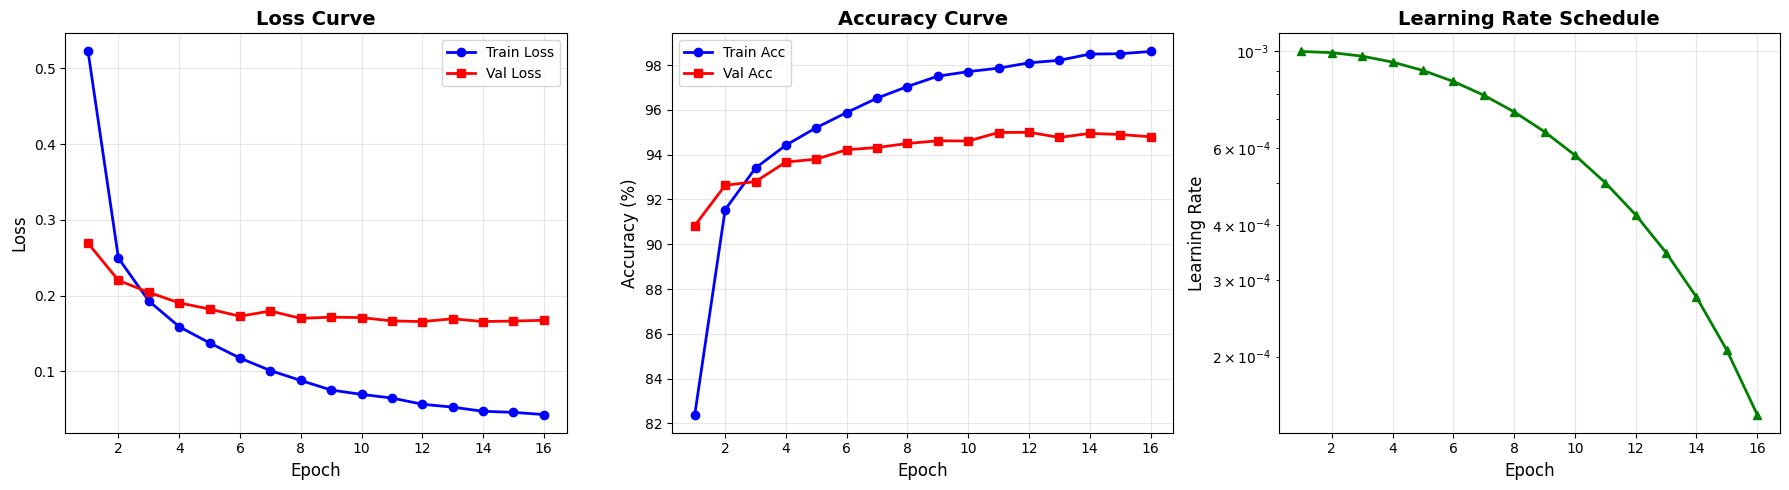

최종 학습 결과
최종 훈련 손실: 0.0428
최종 훈련 정확도: 98.61%
최종 검증 손실: 0.1673
최종 검증 정확도: 94.80%
최고 검증 정확도: 95.00%


In [60]:
# 학습 곡선 시각화
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 손실 곡선
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # 정확도 곡선
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # 학습률 변화
    axes[2].plot(epochs, history['lr'], 'g-^', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_yscale('log')  # 로그 스케일

    plt.tight_layout()
    plt.show()

    # 최종 결과 출력
    print('=' * 60)
    print('최종 학습 결과')
    print('=' * 60)
    print(f'최종 훈련 손실: {history["train_loss"][-1]:.4f}')
    print(f'최종 훈련 정확도: {history["train_acc"][-1]:.2f}%')
    print(f'최종 검증 손실: {history["val_loss"][-1]:.4f}')
    print(f'최종 검증 정확도: {history["val_acc"][-1]:.2f}%')
    print(f'최고 검증 정확도: {max(history["val_acc"]):.2f}%')
    print('=' * 60)

# 시각화 실행
plot_history(history)

혼동행렬

In [62]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='predicting'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

predicting: 100%|██████████| 157/157 [00:14<00:00, 10.68it/s]


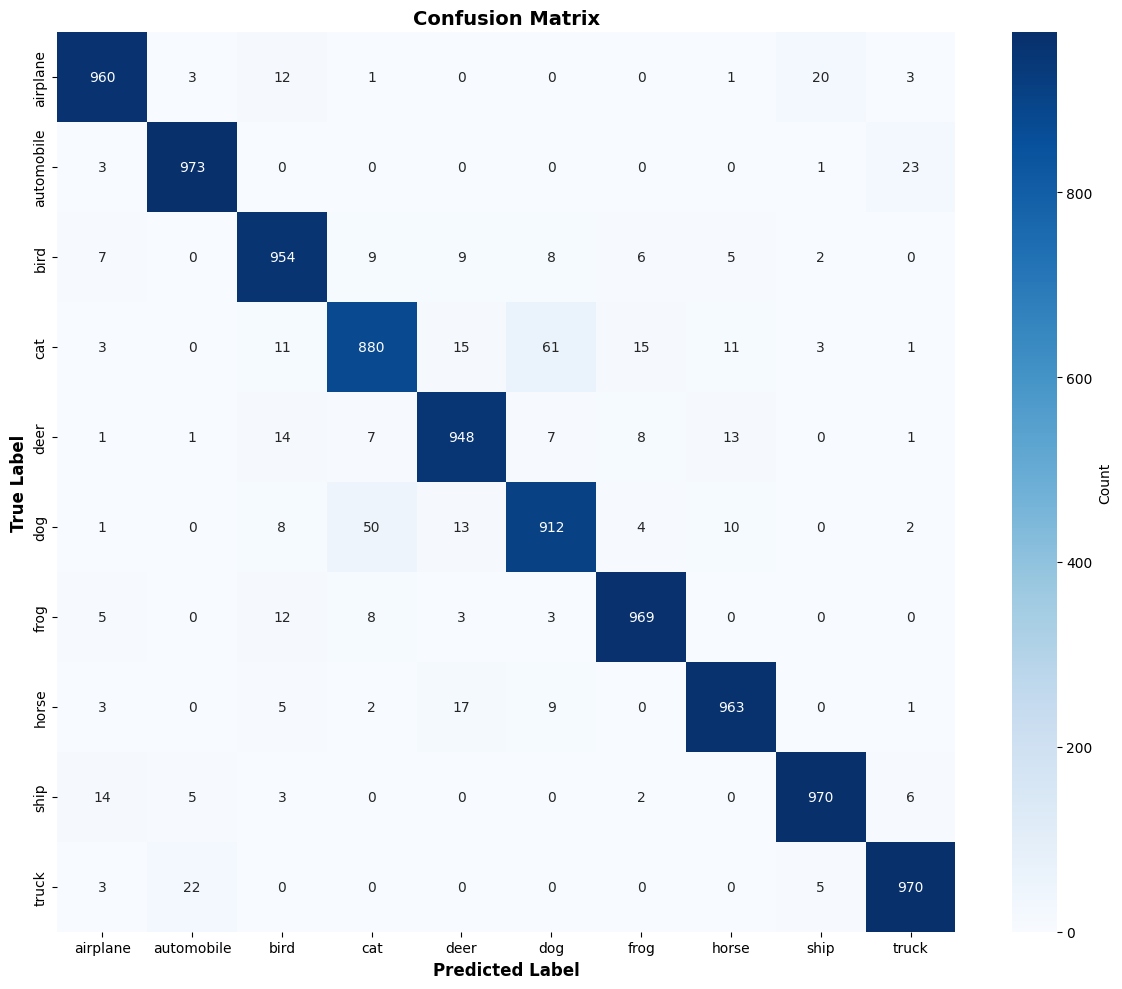


클래스별 정확도:
airplane    :  96.00%
automobile  :  97.30%
bird        :  95.40%
cat         :  88.00%
deer        :  94.80%
dog         :  91.20%
frog        :  96.90%
horse       :  96.30%
ship        :  97.00%
truck       :  97.00%


상세 분류 리포트:
              precision    recall  f1-score   support

    airplane     0.9600    0.9600    0.9600      1000
  automobile     0.9691    0.9730    0.9711      1000
        bird     0.9362    0.9540    0.9450      1000
         cat     0.9195    0.8800    0.8993      1000
        deer     0.9433    0.9480    0.9456      1000
         dog     0.9120    0.9120    0.9120      1000
        frog     0.9651    0.9690    0.9671      1000
       horse     0.9601    0.9630    0.9616      1000
        ship     0.9690    0.9700    0.9695      1000
       truck     0.9633    0.9700    0.9666      1000

    accuracy                         0.9499     10000
   macro avg     0.9498    0.9499    0.9498     10000
weighted avg     0.9498    0.9499    0.9498     1000

In [63]:
# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred, class_names):
    # 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)

    # 시각화
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 클래스별 정확도 계산
    class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

    print('\n클래스별 정확도:')
    print('=' * 40)
    for i, (name, acc) in enumerate(zip(class_names, class_accuracy)):
        print(f'{name:12s}: {acc:6.2f}%')
    print('=' * 40)

# 예측 및 시각화
y_pred, y_true = get_predictions(model, val_loader, device)
plot_confusion_matrix(y_true, y_pred, class_names)

# 분류 리포트 출력
print('\n\n상세 분류 리포트:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

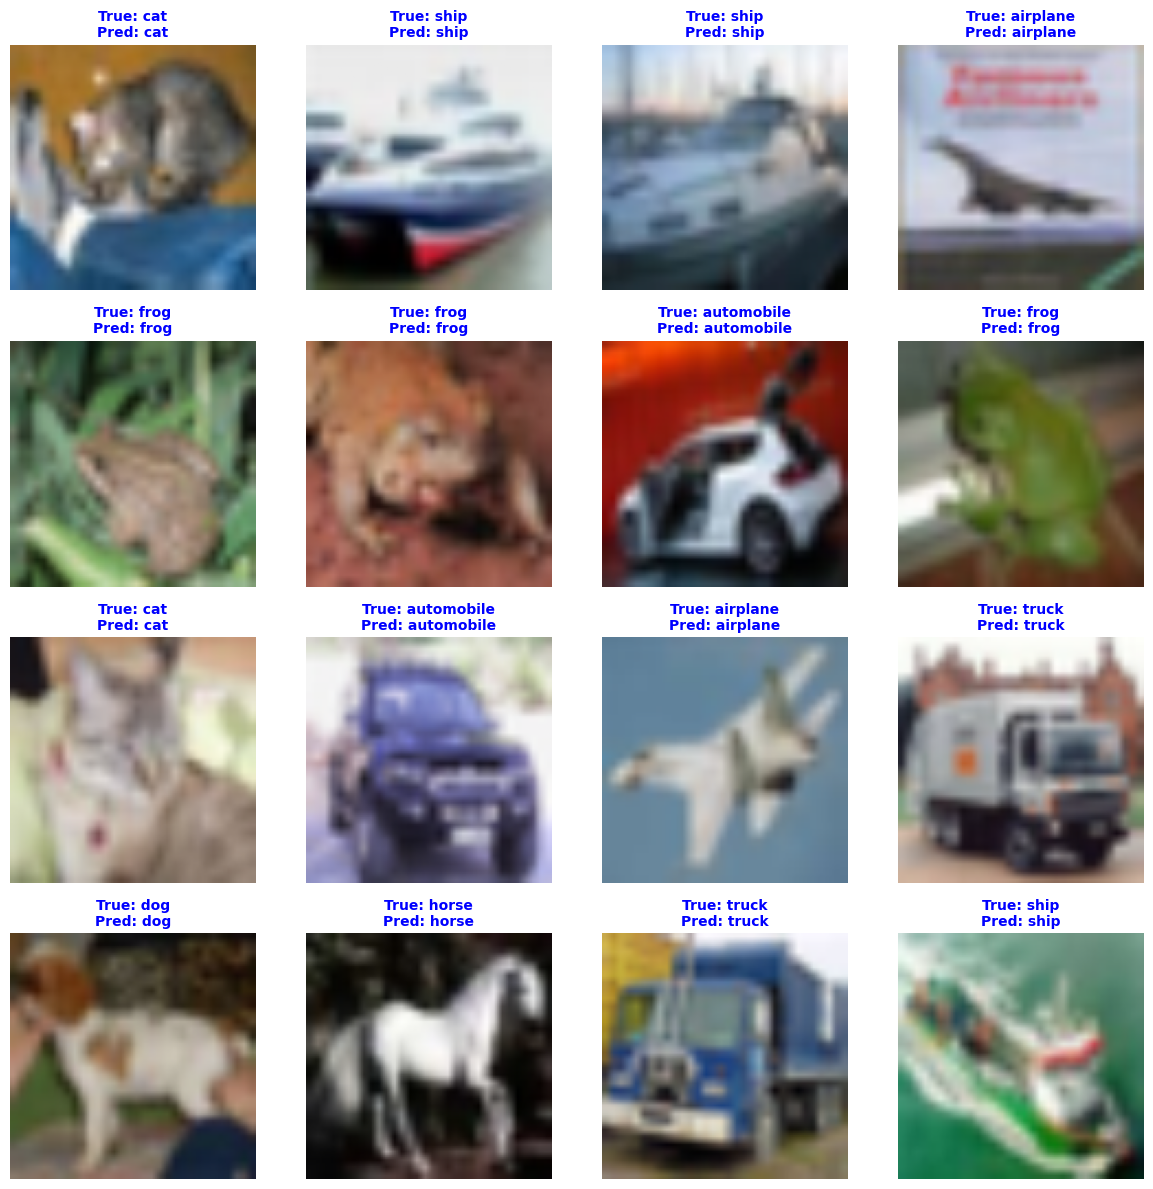

In [64]:
# 샘플 예측 시각화
def visualize_predictions(model, loader, class_names, device, num_images=16):
    model.eval()

    # 데이터 가져오기
    dataiter = iter(loader)
    images, labels = next(dataiter)
    images = images[:num_images]
    labels = labels[:num_images]

    # 예측
    with torch.no_grad():
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

    # 이미지 역정규화
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    # view(3,1,1)
    # torch.tensor([0.485, 0.456, 0.406]) (3) (1차원)
    # >> torch.tensor([0.485, 0.456, 0.406]).view(3,1,1) >> (3,1,1) (3차원)
    # >> pytorch가 자동으로 브로드캐스팅 (3,244,244)


    # 시각화
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.ravel()

    for idx in range(num_images):
        img = images[idx].permute(1, 2, 0).numpy()
        # pytorch 이미지 형식 (CHW) >> (HWC)
        true_label = class_names[labels[idx]]
        pred_label = class_names[predicted[idx]]

        # 올바른 예측은 파란색, 잘못된 예측은 빨간색
        color = 'blue' if labels[idx] == predicted[idx] else 'red'

        axes[idx].imshow(img)
        axes[idx].set_title(
            f'True: {true_label}\nPred: {pred_label}',
            color=color,
            fontsize=10,
            fontweight='bold'
        )
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# 샘플 예측 시각화 실행
visualize_predictions(model, val_loader, class_names, device, num_images=16)